In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self.grad = 0
        self._backward = lambda : None
        self._op = _op
        self.label = label


    def __repr__(self):
        return f"value(data={self.data})"
    
    def __rmul__(self, other):
        return self * other
    
    def __radd__(self, other):
        return self + other
    
    def __rsub__(self, other):
        return other + (-self)
    
    def __neg__(self):
        return self * -1
    
    def __truediv__(self, other):
        return self * other**-1

    def __sub__(self, other):
        return self + (-other)
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1 * out.grad
            other.grad += 1 * out.grad
        out._backward = _backward
        return out

    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad 
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        assert isinstance(other, (int,float)), "Only supporting int and float for power"
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) *out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out
    
    def backward(self):
        # topological sort
        topo = []
        visited = set()
        def build(v):
            if v not in visited:
                visited.add(v)
                
                for child in v._prev:
                    build(child)
                
                topo.append(v)
        
        build(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
            
    


In [3]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir':'LR'})

    nodes, edges = trace(root)
    
    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label= f" {n.label} | data {n.data:.4f} | grad {n.grad:.4f}", shape="rect" )

        if n._op:
            dot.node(name= uid + n._op, label= n._op)
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2))+ n2._op)
    
    return dot

In [4]:
# topological sort
topo = []
visited = set()
def build(v):
    if v not in visited:
        visited.add(n)

        for child in v._prev:
            build(child)
        topo.append(v)
    return topo

In [5]:
# inputs x1,x2
x1 = Value(2.0,label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1+x2w2 ; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

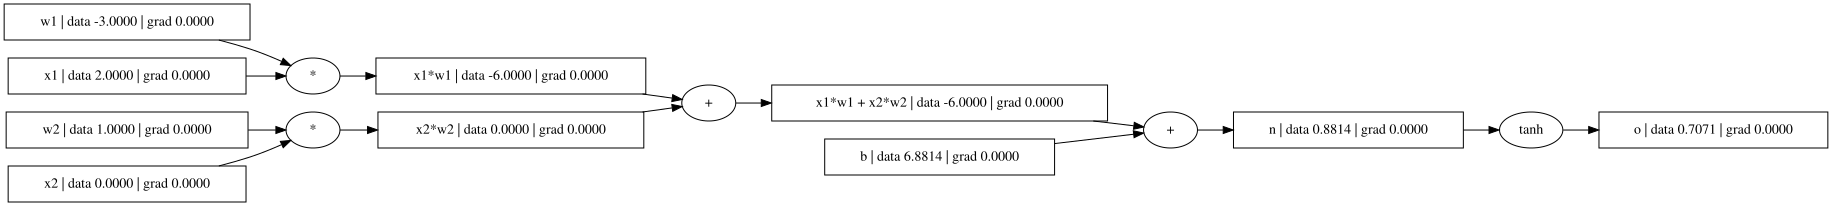

In [6]:
draw_dot(o)

In [7]:
# manual backward
o.grad = 1
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x2w2._backward()
x1w1._backward()

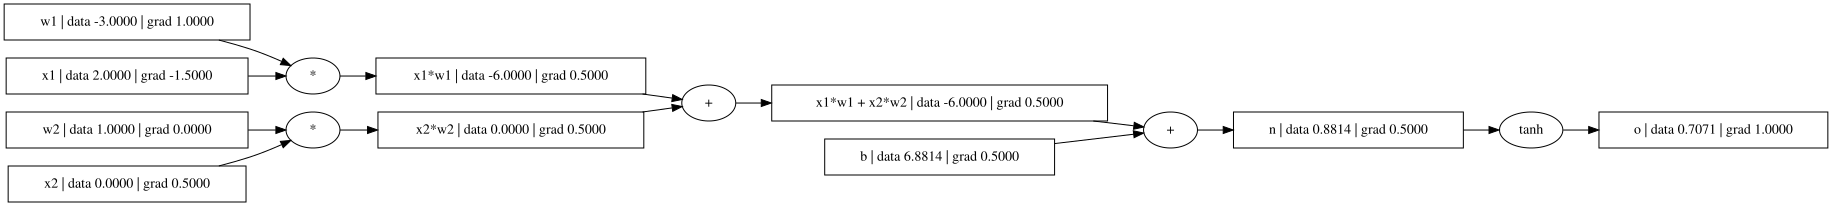

In [8]:
draw_dot(o)

In [9]:
# inputs x1,x2
x1 = Value(2.0,label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1+x2w2 ; x1w1x2w2.label = 'x1*w1 + x2*w2'
x = x1w1x2w2 + b; n.label = 'x'
e = (2*x).exp(); e.label = 'e'
t = (e - 1) / (e + 1); t.label = 't'
t.backward()

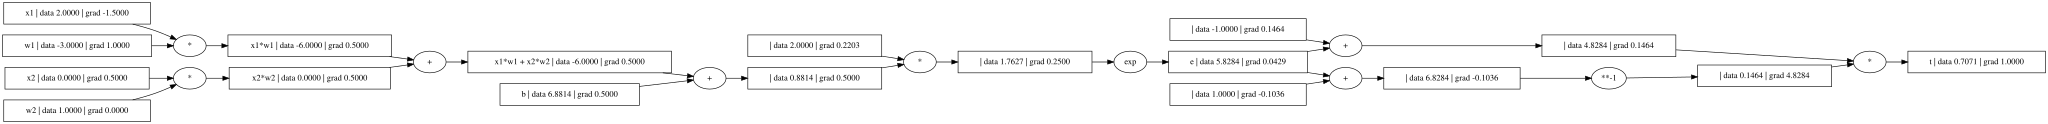

In [10]:
draw_dot(t)

In [11]:
# inputs x1,x2
x1 = Value(2.0,label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1+x2w2 ; x1w1x2w2.label = 'x1*w1 + x2*w2'
x = x1w1x2w2 + b; n.label = 'x'
e = (2*x).exp(); e.label = 'e'
t = (e - 1) / (e + 1); t.label = 't'
t.backward()

In [12]:
# verify with pytorch
import torch
x1 = torch.tensor([2.0]).double() ; x1.requires_grad = True
x2 = torch.tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.tensor([1.0]).double(); w2.requires_grad = True
b = torch.tensor([6.8813735870195432,]).double(); b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('----')
print('x1', x1.grad.item())
print('x2', x2.grad.item())
print('w1', w1.grad.item())
print('w2', w2.grad.item())


0.7071066904050358
----
x1 -1.5000003851533106
x2 0.5000001283844369
w1 1.0000002567688737
w2 0.0


In [13]:
import random

class Neuron():
    def __init__(self, nin):
        # initialize weights and bias
        self.w = [ Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
        
    def __call__(self,x):
        # forward path w*x+b
        act = sum((xi*wi for xi,wi in zip(x,self.w)),self.b)
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]

class Layer():
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP():
    def __init__(self, nin, nouts):
        size = [nin] + nouts
        self.layers = [Layer(size[i],size[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        acts = x
        for layer in self.layers:
             acts = layer(acts) # the output of one layer becomes the input to the next layer
        return acts
        
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters() ]


In [14]:
x = [2.0, 4.0, -1.0]
n = MLP(3,[3,3,1])
n(x)

value(data=0.3740202806868072)

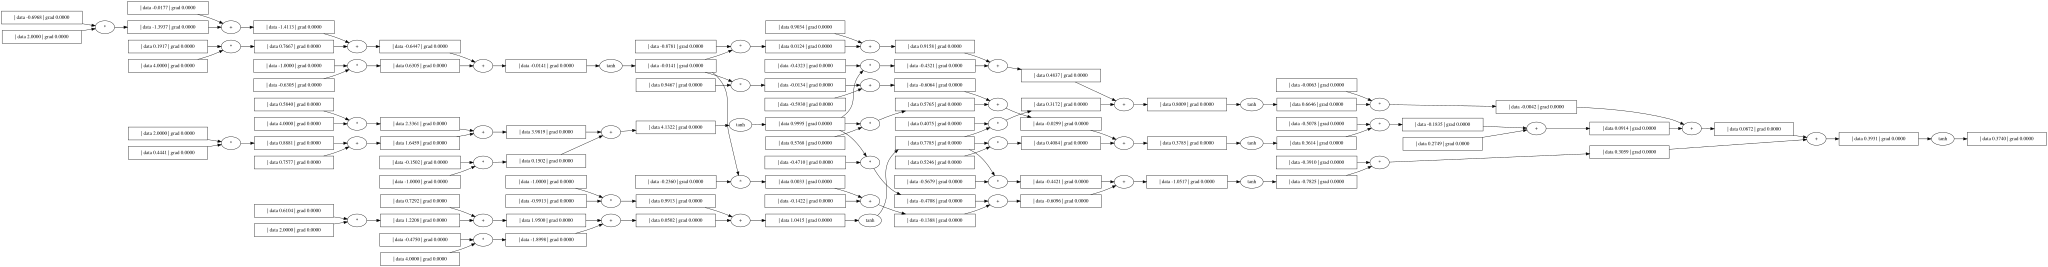

In [15]:
draw_dot(n(x))

In [94]:
# multiple inputs
X = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.1, 1.0, -1.0]
]

# targets
Y = [1.0, -1.0, -1.0, 1.0] 

# Initialize the neural network
N = MLP(3,[3,3,1])

In [105]:
# gradient descent
learning_rate = 0.1

for k in range(50):

    # forward pass
    y_pred = [N(x) for x in X]
    loss = sum((y_hat-y)**2  for y, y_hat in zip(Y,y_pred))

    # backward pass
    for p in N.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in N.parameters():
        p.data += -learning_rate * p.grad

    print(k, loss.data)

0 0.001579125556374576
1 0.0015750119365524665
2 0.001570919273073571
3 0.0015668474072236586
4 0.0015627961818816271
5 0.0015587654414996712
6 0.0015547550320835944
7 0.0015507648011735724
8 0.0015467945978250783
9 0.0015428442725902041
10 0.0015389136774991517
11 0.0015350026660420622
12 0.0015311110931511087
13 0.0015272388151827939
14 0.001523385689900595
15 0.00151955157645781
16 0.001515736335380624
17 0.0015119398285515391
18 0.001508161919192872
19 0.001504402471850631
20 0.001500661352378562
21 0.0014969384279224726
22 0.0014932335669047025
23 0.0014895466390089198
24 0.0014858775151649658
25 0.0014822260675341605
26 0.0014785921694946134
27 0.00147497569562681
28 0.0014713765216994115
29 0.0014677945246552714
30 0.001464229582597609
31 0.001460681574776378
32 0.001457150381574864
33 0.0014536358844964433
34 0.001450137966151547
35 0.0014466565102447542
36 0.0014431914015621476
37 0.001439742525958741
38 0.0014363097703462033
39 0.0014328930226806124
40 0.001429492171950582
41

In [106]:
y_pred

[value(data=0.982544052592561),
 value(data=-0.9755682042716712),
 value(data=-0.9879965285842505),
 value(data=0.9811884081412909)]